In [1]:
###Step 1: Import Libraries
!pip install yfinance numpy pandas matplotlib

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
##Step 2: Download Stock Data

#get real world stock prices so we can calculate the rsi and build our strategy
data = yf.download('AAPL', start='2025-01-01',end='2026-01-01')
data.head()


/tmp/ipython-input-2707811158.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2025-01-01',end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.752106,247.978468,240.731247,247.809220,55740700
2025-01-03,242.264297,243.080598,240.800915,242.264297,40244100
2025-01-06,243.896927,246.216438,242.105028,243.210031,45045600
2025-01-07,241.119476,244.444435,240.263348,241.885999,40856000
2025-01-08,241.607269,242.612732,238.969207,240.830782,37628900


In [8]:
##Step 3: Calculate RSI
#unction to calculate rsi

def calculate_rsi(series, period=14):
  delta = series.diff()
  gain =  (delta.where(delta > 0, 0)).rolling(window=period).mean()
  loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
  rs = gain / loss
  return 100 - (100 / (1 + rs))
data['RSI'] = calculate_rsi(data['Close'])

In [9]:
##Step 4: Create Buy/Sell Signals

data['Signal'] = 0
data.loc[data['RSI'] < 30, 'Signal'] = 1
data.loc[data['RSI'] > 70, 'Signal'] = -1
data['Position'] = data['Signal'].diff()

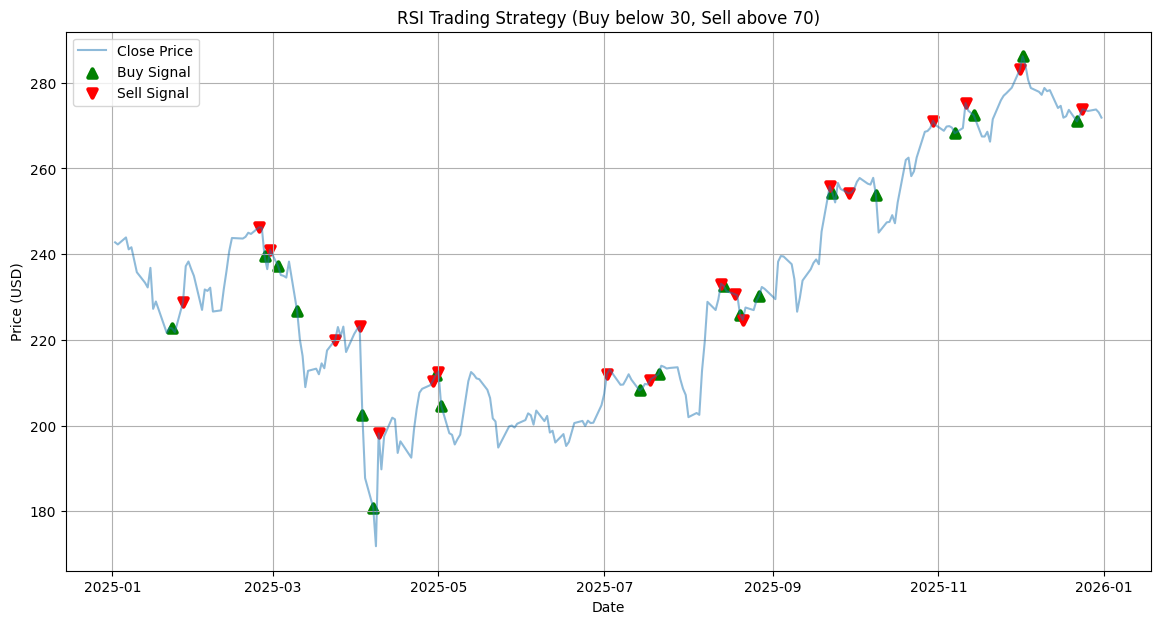

In [11]:
##Step 5: Plot RSI Strategy
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.scatter(data.index[data['Position'] == 1], data['Close'][data['Position'] == 1], lw=3 , label='Buy Signal', marker='^', color='green')
plt.scatter(data.index[data['Position'] == -1], data['Close'][data['Position'] == -1], lw=3 , label='Sell Signal', marker='v', color='red')
plt.title('RSI Trading Strategy (Buy below 30, Sell above 70)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()